<a href="https://colab.research.google.com/github/dimasrhesky270206/Pcvk_SEMESTER-5/blob/main/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

In [10]:
def convolution2d(image, kernel, padding=0):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Menambahkan padding pada gambar jika diperlukan
    if padding:
        padded_image = np.pad(
            image,
            pad_width=padding,
            mode='constant'
        )
    else:
        padded_image = image.copy()

    # Menentukan ukuran hasil konvolusi
    result_h = padded_image.shape[0] - ker_h + 1
    result_w = padded_image.shape[1] - ker_w + 1

    result = np.zeros((result_h, result_w))

    # Proses konvolusi
    for row in range(result_h):
        for col in range(result_w):
            area = padded_image[
                row:row + ker_h,
                col:col + ker_w
            ]

            result[row, col] = np.sum(area * kernel)

    return result

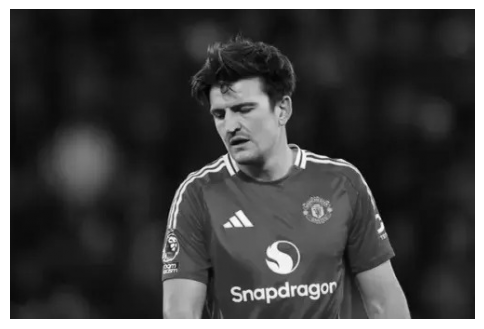

In [11]:
img = cv.imread('/content/drive/MyDrive/pcvk/harryMaguaire.tiff')

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

E. Menentukan Kernel Sharpening

In [12]:
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

print(kernel_sharpen)

[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


F. Memanggil Fungsi Konvolusi + Menampilkan Hasil

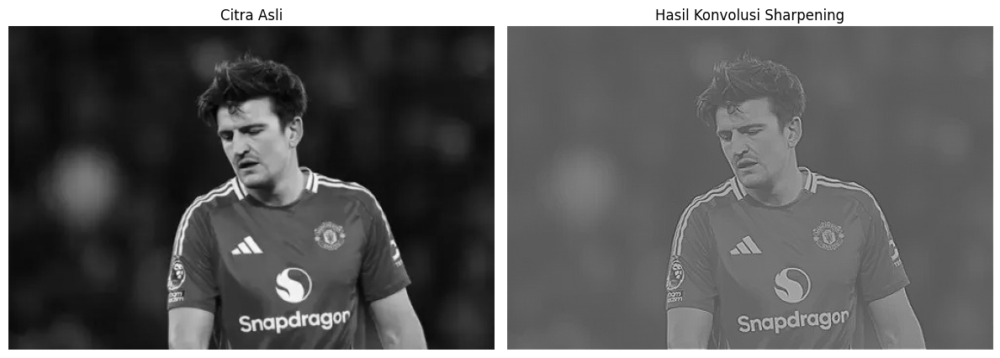

In [13]:
hasil_konvolusi = convolution2d(img_gray, kernel_sharpen, padding=1)

plt.figure(figsize=(12, 5))

# Menampilkan citra awal
plt.subplot(121)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

# Menampilkan hasil sharpening
plt.subplot(122)
plt.imshow(hasil_konvolusi, cmap='gray')
plt.title('Hasil Konvolusi Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

D.3 Image Filter

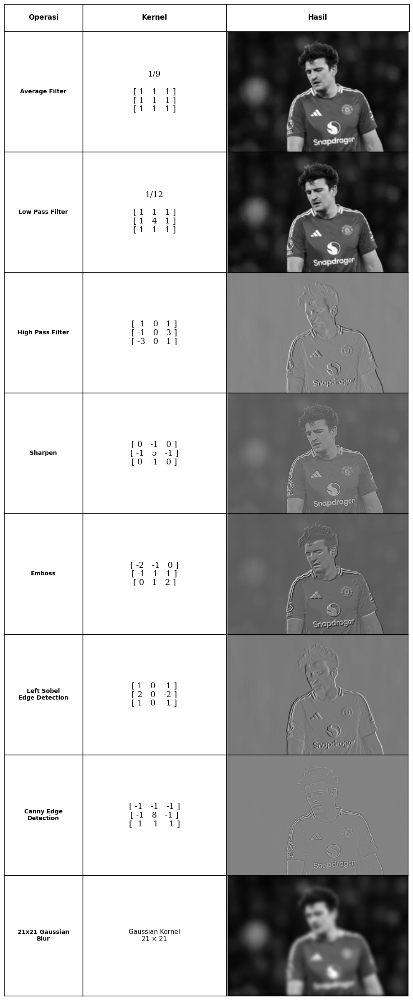

In [16]:
# NOMOR 3 - IMAGE FILTER

# Membuat kernel filter
kernel_average = np.ones((3, 3)) / 9

kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
]) / 12

kernel_highpass = np.array([
    [-1, 0, 1],
    [-1, 0, 3],
    [-3, 0, 1]
])

kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

kernel_emboss = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
])

kernel_left_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

kernel_canny = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])


# Melakukan proses konvolusi pada setiap filter
hasil_average = convolution2d(img_gray, kernel_average, padding=1)
hasil_lowpass = convolution2d(img_gray, kernel_lowpass, padding=1)
hasil_highpass = convolution2d(img_gray, kernel_highpass, padding=1)
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, padding=1)
hasil_emboss = convolution2d(img_gray, kernel_emboss, padding=1)
hasil_left_sobel = convolution2d(img_gray, kernel_left_sobel, padding=1)
hasil_canny = convolution2d(img_gray, kernel_canny, padding=1)


# Membuat kernel Gaussian 21 x 21
kernel_size = 21
sigma = math.sqrt(kernel_size)

gauss_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = np.dot(gauss_1d, gauss_1d.T)

hasil_gaussian = convolution2d(
    img_gray,
    gauss_kernel,
    padding=10
)


# Menyimpan nama, kernel, dan hasil filter
filter_data = [
    ("Average Filter", kernel_average, hasil_average),
    ("Low Pass Filter", kernel_lowpass, hasil_lowpass),
    ("High Pass Filter", kernel_highpass, hasil_highpass),
    ("Sharpen", kernel_sharpen, hasil_sharpen),
    ("Emboss", kernel_emboss, hasil_emboss),
    ("Left Sobel\nEdge Detection", kernel_left_sobel, hasil_left_sobel),
    ("Canny Edge\nDetection", kernel_canny, hasil_canny),
    ("21x21 Gaussian\nBlur", gauss_kernel, hasil_gaussian)
]


# Membuat layout tabel
fig = plt.figure(figsize=(10, 24))

grid = fig.add_gridspec(
    nrows=len(filter_data) + 1,
    ncols=3,
    width_ratios=[1.2, 2.2, 2.8],
    height_ratios=[0.45] + [2] * len(filter_data),
    hspace=0,
    wspace=0
)


# Bagian judul tabel
for col, title in enumerate(["Operasi", "Kernel", "Hasil"]):

    cell = fig.add_subplot(grid[0, col])

    cell.text(
        0.5,
        0.5,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    cell.set_xticks([])
    cell.set_yticks([])

    for border in cell.spines.values():
        border.set_visible(True)
        border.set_linewidth(1)


# Menampilkan setiap filter
for row, (filter_name, filter_kernel, filter_result) in enumerate(
    filter_data, start=1
):

    # Kolom nama operasi
    operation_ax = fig.add_subplot(grid[row, 0])

    operation_ax.text(
        0.5,
        0.5,
        filter_name,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    operation_ax.set_xticks([])
    operation_ax.set_yticks([])

    for border in operation_ax.spines.values():
        border.set_visible(True)
        border.set_linewidth(1)


    # Kolom kernel
    kernel_ax = fig.add_subplot(grid[row, 1])
    kernel_ax.set_xticks([])
    kernel_ax.set_yticks([])

    if filter_name == "Average Filter":

        kernel_display = (
            "1/9\n\n"
            "[ 1   1   1 ]\n"
            "[ 1   1   1 ]\n"
            "[ 1   1   1 ]"
        )

        kernel_ax.text(
            0.5, 0.5,
            kernel_display,
            ha="center",
            va="center",
            fontsize=14,
            family="serif"
        )

    elif filter_name == "Low Pass Filter":

        kernel_display = (
            "1/12\n\n"
            "[ 1   1   1 ]\n"
            "[ 1   4   1 ]\n"
            "[ 1   1   1 ]"
        )

        kernel_ax.text(
            0.5, 0.5,
            kernel_display,
            ha="center",
            va="center",
            fontsize=14,
            family="serif"
        )

    elif filter_kernel.shape == (21, 21):

        kernel_ax.text(
            0.5,
            0.5,
            "Gaussian Kernel\n21 × 21",
            ha="center",
            va="center",
            fontsize=11
        )

    else:

        kernel_display = "\n".join(
            "[ " + "   ".join(str(int(x)) for x in line) + " ]"
            for line in filter_kernel
        )

        kernel_ax.text(
            0.5,
            0.5,
            kernel_display,
            ha="center",
            va="center",
            fontsize=14,
            family="serif"
        )

    for border in kernel_ax.spines.values():
        border.set_visible(True)
        border.set_linewidth(1)


    # Kolom hasil gambar
    result_ax = fig.add_subplot(grid[row, 2])

    result_ax.imshow(
        filter_result,
        cmap="gray"
    )

    result_ax.set_xticks([])
    result_ax.set_yticks([])

    for border in result_ax.spines.values():
        border.set_visible(True)
        border.set_linewidth(1)


plt.tight_layout()
plt.show()

E. FILTER LIBRARY DAN FILTER MODERN

In [21]:
import os

path_gambar = "/content/drive/MyDrive/pcvk/lena.jpg"

print(os.path.exists(path_gambar))

False


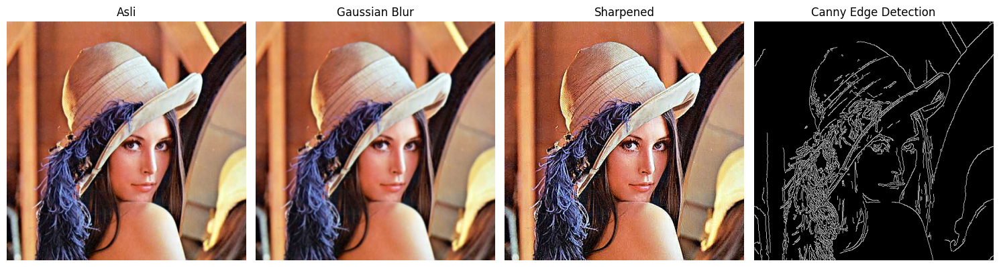

In [22]:
# E. FILTER LIBRARY DAN FILTER MODERN - Percobaan 1

def tampilkan_gambar(gambar_list, judul_list, ukuran=(15, 5)):
    jumlah = len(gambar_list)

    plt.figure(figsize=ukuran)

    for nomor, gambar in enumerate(gambar_list):
        posisi = nomor + 1

        plt.subplot(1, jumlah, posisi)

        if gambar.ndim == 2:
            plt.imshow(gambar, cmap="gray")
        else:
            gambar_rgb = cv.cvtColor(gambar, cv.COLOR_BGR2RGB)
            plt.imshow(gambar_rgb)

        plt.title(judul_list[nomor])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Membaca gambar
gambar = cv.imread(
    "/content/drive/MyDrive/pcvk/lena.jpg"
)

# Mengubah gambar menjadi grayscale
gray = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY)


# Gaussian Blur
hasil_blur = cv.GaussianBlur(
    gambar,
    (7, 7),
    1
)


# Deteksi tepi menggunakan Canny
hasil_canny = cv.Canny(
    gray,
    100,
    200
)


# Kernel untuk proses sharpening
kernel_tajam = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])


# Melakukan sharpening menggunakan filter2D
hasil_sharpen = cv.filter2D(
    gambar,
    -1,
    kernel_tajam
)


# Menampilkan seluruh hasil
tampilkan_gambar(
    [gambar, hasil_blur, hasil_sharpen, hasil_canny],
    [
        "Asli",
        "Gaussian Blur",
        "Sharpened",
        "Canny Edge Detection"
    ]
)

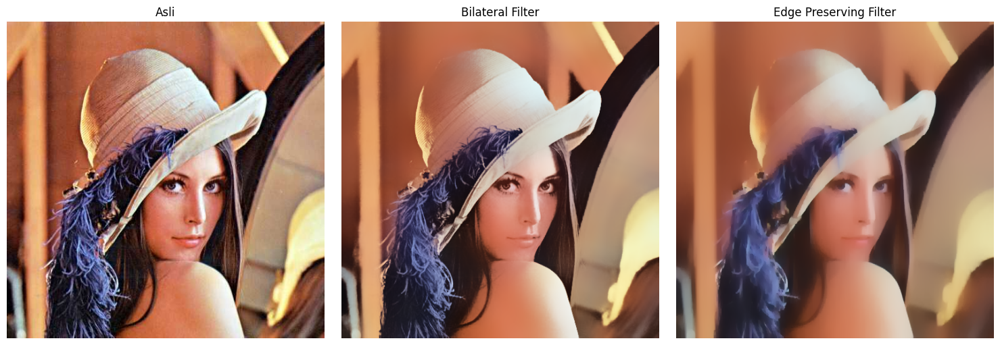

In [23]:
# Percobaan 2 - Filter Modern dari OpenCV

lokasi_file = "/content/drive/MyDrive/pcvk/lena.jpg"

gambar = cv.imread(lokasi_file)

# Bilateral Filter
hasil_bilateral = cv.bilateralFilter(
    gambar,
    50,
    100,
    100
)

# Edge Preserving Filter
hasil_edge_preserve = cv.edgePreservingFilter(
    gambar,
    flags=1,
    sigma_s=100,
    sigma_r=0.9
)

# Menampilkan hasil
tampilkan_gambar(
    [gambar, hasil_bilateral, hasil_edge_preserve],
    [
        "Asli",
        "Bilateral Filter",
        "Edge Preserving Filter"
    ]
)

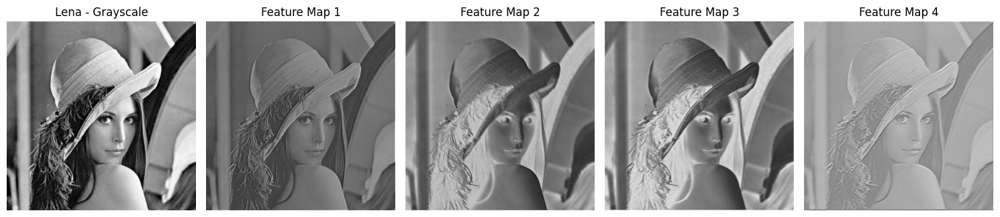

In [27]:
# Percobaan 3 - Feature Map pada CNN

import cv2 as cv
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# Membaca gambar Lena
path_lena = "/content/drive/MyDrive/pcvk/lena.jpg"
gambar_lena = cv.imread(path_lena)

# Konversi ke grayscale
lena_gray = cv.cvtColor(
    gambar_lena,
    cv.COLOR_BGR2GRAY
)


# Membuat CNN sederhana
class CNN_Sederhana(nn.Module):
    def __init__(self):
        super().__init__()

        self.konvolusi = nn.Conv2d(
            1,
            4,
            kernel_size=3,
            stride=1,
            padding=1
        )

    def forward(self, data):
        return self.konvolusi(data)


# Inisialisasi model
model_cnn = CNN_Sederhana()


# Mengubah gambar menjadi tensor
tensor_lena = torch.tensor(
    lena_gray,
    dtype=torch.float32
)

tensor_lena = tensor_lena.unsqueeze(0).unsqueeze(0)
tensor_lena = tensor_lena / 255.0


# Proses feature extraction
with torch.no_grad():
    output_fitur = model_cnn(tensor_lena)


# Menyimpan feature map
feature_list = []

for i in range(output_fitur.shape[1]):
    feature_list.append(
        output_fitur[0, i].numpy()
    )


# Membuat judul gambar
judul_fitur = ["Lena - Grayscale"]

for i in range(len(feature_list)):
    judul_fitur.append(f"Feature Map {i + 1}")


# Menampilkan gambar dan feature map
tampilkan_gambar(
    [lena_gray] + feature_list,
    judul_fitur
)

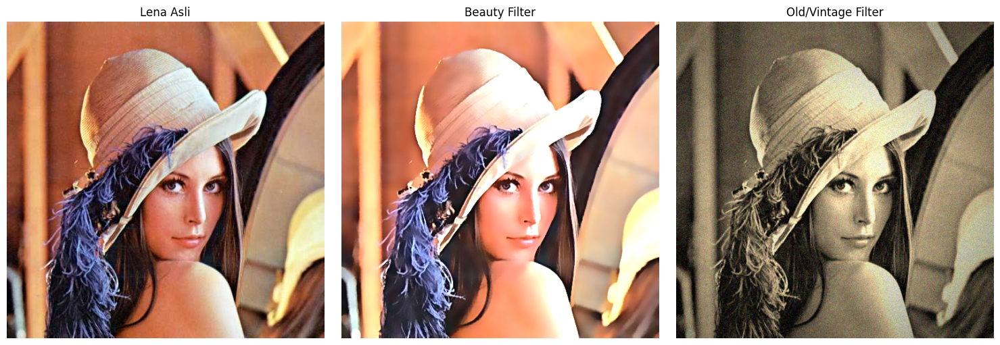

In [28]:
# Percobaan 4 - Beauty dan Vintage Filter

# Membaca gambar Lena
file_lena = "/content/drive/MyDrive/pcvk/lena.jpg"
gambar = cv.imread(file_lena)


# =========================
# BEAUTY FILTER
# =========================

hasil_smooth = cv.bilateralFilter(
    gambar,
    15,
    75,
    75
)

hasil_blur = cv.GaussianBlur(
    hasil_smooth,
    (0, 0),
    3
)

hasil_tajam = cv.addWeighted(
    hasil_smooth,
    1.5,
    hasil_blur,
    -0.5,
    0
)

hasil_beauty = cv.convertScaleAbs(
    hasil_tajam,
    alpha=1.2,
    beta=15
)


# =========================
# OLD / VINTAGE FILTER
# =========================

matriks_sepia = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])

hasil_sepia = cv.transform(
    gambar,
    matriks_sepia
)

hasil_sepia = np.clip(
    hasil_sepia,
    0,
    255
).astype(np.uint8)


# Membuat efek vignette
tinggi_gambar, lebar_gambar = gambar.shape[:2]

gauss_y = cv.getGaussianKernel(
    tinggi_gambar,
    lebar_gambar * 0.6
)

gauss_x = cv.getGaussianKernel(
    lebar_gambar,
    lebar_gambar * 0.6
)

mask = gauss_y @ gauss_x.T
mask = mask / mask.max()


# Menerapkan vignette
hasil_vignette = hasil_sepia.copy()

for kanal in range(3):
    nilai = hasil_vignette[:, :, kanal] * mask
    hasil_vignette[:, :, kanal] = nilai.astype(np.uint8)


# Menambahkan noise
gangguan = np.random.normal(
    0,
    15,
    hasil_vignette.shape
).astype(np.int16)

hasil_vintage = np.clip(
    hasil_vignette.astype(np.int16) + gangguan,
    0,
    255
).astype(np.uint8)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [gambar, hasil_beauty, hasil_vintage],
    [
        "Lena Asli",
        "Beauty Filter",
        "Old/Vintage Filter"
    ]
)

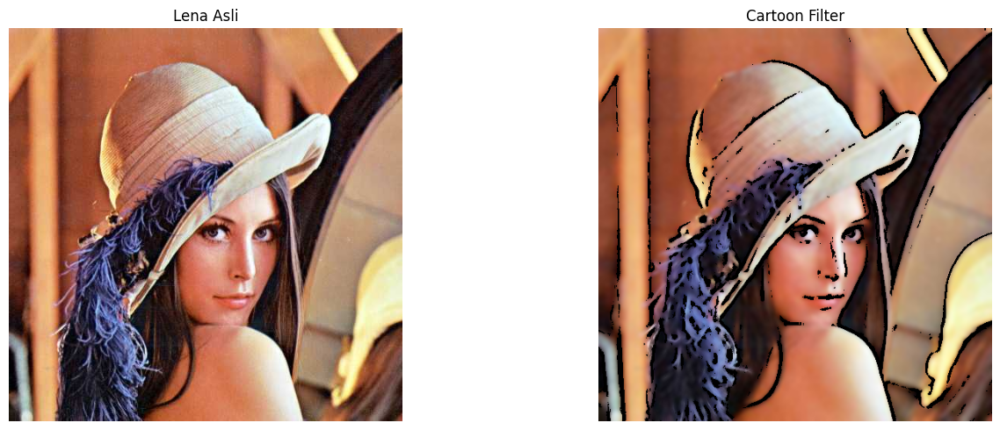

In [29]:
# Percobaan 5 - Anime / Cartoon Filter

# Membaca gambar Lena
path_gambar = "/content/drive/MyDrive/pcvk/lena.jpg"
gambar_lena = cv.imread(path_gambar)


# =========================
# STEP 1 - EDGE DETECTION
# =========================

abu_abu = cv.cvtColor(
    gambar_lena,
    cv.COLOR_BGR2GRAY
)

abu_abu_halus = cv.medianBlur(
    abu_abu,
    7
)

garis_tepi = cv.adaptiveThreshold(
    abu_abu_halus,
    255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    9,
    9
)


# =========================
# STEP 2 - BILATERAL FILTER
# =========================

warna_halus = cv.bilateralFilter(
    gambar_lena,
    9,
    200,
    200
)


# =========================
# STEP 3 - MENGGABUNGKAN
# =========================

hasil_cartoon = cv.bitwise_and(
    warna_halus,
    warna_halus,
    mask=garis_tepi
)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [gambar_lena, hasil_cartoon],
    [
        "Lena Asli",
        "Cartoon Filter"
    ]
)

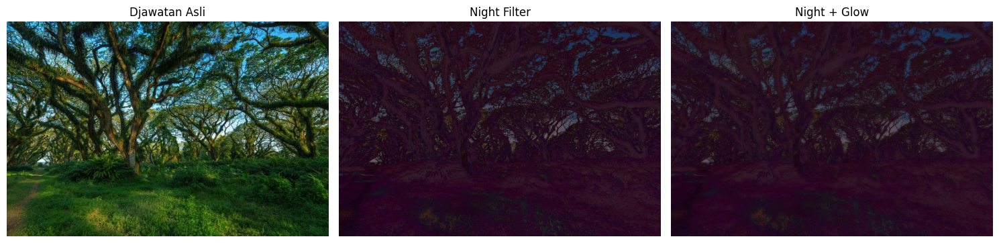

In [30]:
# Percobaan 6 - Night Filter

# Membaca gambar Djawatan
lokasi_gambar = "/content/drive/MyDrive/pcvk/djawatan.jpg"
gambar = cv.imread(lokasi_gambar)


# =========================
# STEP 1 - MEMBUAT GAMBAR GELAP
# =========================

hasil_gelap = cv.convertScaleAbs(
    gambar,
    alpha=0.6,
    beta=-40
)


# =========================
# STEP 2 - MEMBERIKAN WARNA BIRU
# =========================

lapisan_biru = np.full_like(
    hasil_gelap,
    (50, 0, 100)
)

hasil_night = cv.addWeighted(
    hasil_gelap,
    0.8,
    lapisan_biru,
    0.2,
    0
)


# =========================
# STEP 3 - MEMBUAT EFEK GLOW
# =========================

kernel_glow = np.ones(
    (15, 15),
    dtype=np.float32
) / 225

hasil_glow = cv.filter2D(
    hasil_night,
    -1,
    kernel_glow
)


# Menggabungkan gambar dengan efek glow
night_final = cv.addWeighted(
    hasil_night,
    0.7,
    hasil_glow,
    0.3,
    0
)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [gambar, hasil_night, night_final],
    [
        "Djawatan Asli",
        "Night Filter",
        "Night + Glow"
    ]
)

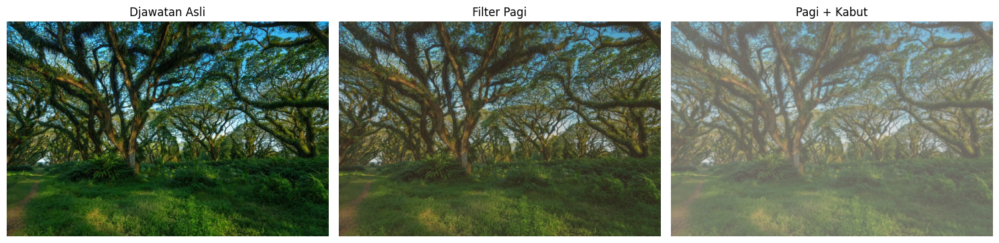

In [32]:
# Percobaan 7 - Filter Pagi dan Kabut

# Membaca gambar Djawatan
path_djawatan = "/content/drive/MyDrive/pcvk/djawatan.jpg"
djawatan = cv.imread(path_djawatan)


# =========================
# STEP 1 - CERAHKAN GAMBAR
# =========================

kontras = 0.9
brightness = 20

gambar_soft = cv.convertScaleAbs(
    djawatan,
    alpha=kontras,
    beta=brightness
)


# =========================
# STEP 2 - WARM TONE
# =========================

tint_hangat = np.full_like(
    gambar_soft,
    (40, 70, 120)
)

gambar_pagi = cv.addWeighted(
    gambar_soft,
    0.8,
    tint_hangat,
    0.2,
    0
)


# =========================
# STEP 3 - EFEK KABUT
# =========================

kernel = cv.getGaussianKernel(
    3,
    3
)

kernel = kernel @ kernel.T

gambar_kabut = cv.filter2D(
    gambar_pagi,
    -1,
    kernel
)


# Lapisan putih untuk membuat kabut
lapisan_putih = np.full_like(
    gambar_pagi,
    255
)

hasil_kabut = cv.addWeighted(
    gambar_kabut,
    0.7,
    lapisan_putih,
    0.3,
    0
)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [djawatan, gambar_pagi, hasil_kabut],
    [
        "Djawatan Asli",
        "Filter Pagi",
        "Pagi + Kabut"
    ]
)

### 1. Tugas Analisis — Mean Filter vs Median Filter

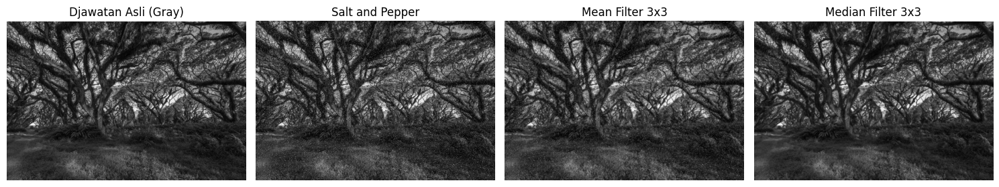

In [33]:
# Tugas 1 - Mean Filter vs Median Filter

# Membaca gambar Djawatan
lokasi = "/content/drive/MyDrive/pcvk/djawatan.jpg"
gambar = cv.imread(lokasi)

# Konversi ke grayscale
gray_djawatan = cv.cvtColor(
    gambar,
    cv.COLOR_BGR2GRAY
)


# =========================
# SALT AND PEPPER NOISE
# =========================

gambar_terganggu = gray_djawatan.copy()

probabilitas = 0.05
nilai_acak = np.random.random(
    gambar_terganggu.shape
)

gambar_terganggu[
    nilai_acak < probabilitas / 2
] = 0

gambar_terganggu[
    nilai_acak > 1 - probabilitas / 2
] = 255


# =========================
# MEAN FILTER
# =========================

hasil_mean = cv.blur(
    gambar_terganggu,
    (3, 3)
)


# =========================
# MEDIAN FILTER
# =========================

hasil_median = cv.medianBlur(
    gambar_terganggu,
    3
)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [
        gray_djawatan,
        gambar_terganggu,
        hasil_mean,
        hasil_median
    ],
    [
        "Djawatan Asli (Gray)",
        "Salt and Pepper",
        "Mean Filter 3x3",
        "Median Filter 3x3"
    ]
)

## Analisis Tugas 1 - Mean Filter vs Median Filter

Pada percobaan ini, gambar Djawatan diubah terlebih dahulu menjadi grayscale kemudian diberikan noise Salt and Pepper dengan probabilitas sebesar 0,05. Noise tersebut menghasilkan titik-titik hitam dan putih secara acak pada gambar.

Setelah noise ditambahkan, digunakan dua metode filtering yaitu Mean Filter dan Median Filter dengan ukuran kernel 3x3.

### Hasil Analisis

**1. Gambar Asli (Gray)**  
Gambar grayscale digunakan sebagai gambar awal sebelum diberikan noise.

**2. Salt and Pepper Noise**  
Setelah noise ditambahkan, muncul bintik-bintik hitam dan putih secara acak pada gambar. Noise ini dapat mengganggu detail dan kualitas gambar.

**3. Mean Filter 3x3**  
Mean Filter mengurangi noise dengan menghitung nilai rata-rata piksel yang berada di dalam area kernel 3x3. Hasilnya gambar menjadi lebih halus, tetapi beberapa detail dan tepi objek juga ikut menjadi blur.

**4. Median Filter 3x3**  
Median Filter mengganti nilai piksel dengan nilai median dari piksel di sekitarnya. Filter ini lebih efektif dalam menghilangkan Salt and Pepper Noise dan tetap mempertahankan tepi objek lebih baik dibandingkan Mean Filter.

### Kesimpulan

Berdasarkan hasil percobaan, **Median Filter 3x3 lebih baik untuk mengurangi Salt and Pepper Noise dibandingkan Mean Filter 3x3**. Mean Filter memang dapat mengurangi noise, tetapi cenderung membuat gambar menjadi lebih blur. Sementara itu, Median Filter mampu membersihkan sebagian besar noise dengan tetap mempertahankan detail dan tepi objek pada gambar.

2. Tugas Evaluasi — Kernel Sharpening 3 × 3 vs 5 × 5

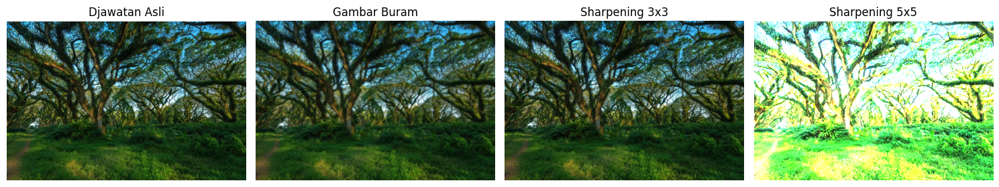

In [34]:
# Tugas 2 - Perbandingan Kernel Sharpening

# Membaca gambar Djawatan
path_file = "/content/drive/MyDrive/pcvk/djawatan.jpg"
djawatan = cv.imread(path_file)


# =========================
# MEMBUAT GAMBAR BURAM
# =========================

gambar_buram = cv.GaussianBlur(
    djawatan,
    (7, 7),
    1.5
)


# =========================
# KERNEL SHARPENING 3x3
# =========================

kernel_3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])


# =========================
# KERNEL SHARPENING 5x5
# =========================

kernel_5 = np.array([
    [0, 0, -1, 0, 0],
    [0, -1, -1, -1, 0],
    [-1, -1, 17, -1, -1],
    [0, -1, -1, -1, 0],
    [0, 0, -1, 0, 0]
])


# =========================
# PROSES SHARPENING
# =========================

hasil_3x3 = cv.filter2D(
    gambar_buram,
    -1,
    kernel_3
)

hasil_5x5 = cv.filter2D(
    gambar_buram,
    -1,
    kernel_5
)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [
        djawatan,
        gambar_buram,
        hasil_3x3,
        hasil_5x5
    ],
    [
        "Djawatan Asli",
        "Gambar Buram",
        "Sharpening 3x3",
        "Sharpening 5x5"
    ]
)

## Analisis Tugas 2 - Perbandingan Kernel Sharpening

Pada percobaan ini, gambar Djawatan terlebih dahulu dibuat sedikit buram menggunakan Gaussian Blur dengan kernel 7x7. Setelah itu, gambar buram diproses menggunakan dua kernel sharpening, yaitu kernel 3x3 dan kernel 5x5.

### Hasil Analisis

**1. Gambar Asli**  
Gambar asli digunakan sebagai acuan sebelum dilakukan proses blur dan sharpening.

**2. Gambar Buram**  
Gaussian Blur membuat gambar menjadi lebih halus dan mengurangi ketajaman detail. Kondisi ini digunakan untuk melihat kemampuan kernel sharpening dalam mengembalikan ketajaman gambar.

**3. Sharpening 3x3**  
Kernel 3x3 mempertajam gambar dengan menonjolkan perbedaan nilai piksel di sekitar piksel utama. Hasilnya tepi objek menjadi lebih jelas dan gambar terlihat lebih tajam.

**4. Sharpening 5x5**  
Kernel 5x5 menggunakan area piksel yang lebih luas sehingga proses penajaman dapat memberikan efek yang lebih kuat. Detail dan tepi objek menjadi lebih menonjol dibandingkan hasil kernel 3x3.

### Perbandingan

Kernel 3x3 memberikan efek sharpening yang lebih sederhana dan cenderung menghasilkan perubahan yang lebih terkontrol. Kernel 5x5 memiliki area pemrosesan yang lebih luas sehingga efek penajamannya lebih kuat, tetapi jika terlalu tinggi dapat menyebabkan beberapa bagian gambar terlihat terlalu tajam.

### Kesimpulan

Berdasarkan hasil percobaan, kedua kernel dapat meningkatkan ketajaman gambar yang sebelumnya buram. **Kernel 3x3 lebih ringan dan menghasilkan penajaman yang lebih terkontrol, sedangkan kernel 5x5 menghasilkan efek penajaman yang lebih kuat.**

### 3. Tugas Kreasi — Fungsi kartun(image)

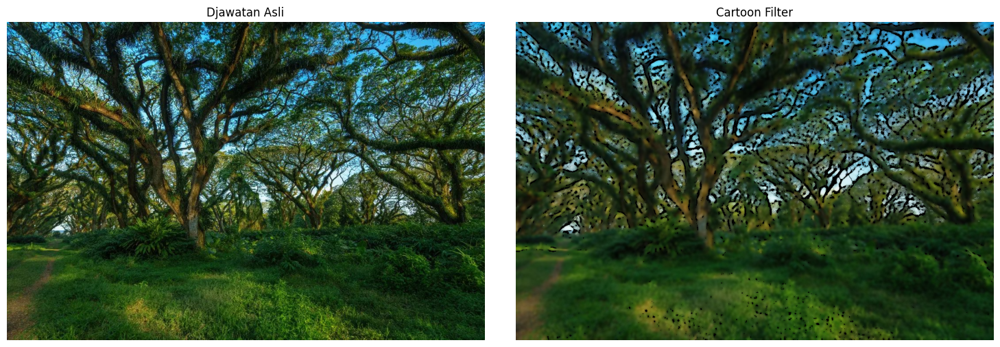

In [35]:
# Tugas 3 - Filter Kartun Sederhana

# Membaca gambar Djawatan
file_gambar = "/content/drive/MyDrive/pcvk/djawatan.jpg"
djawatan = cv.imread(file_gambar)


# =========================
# FUNGSI CARTOON FILTER
# =========================

def buat_kartun(gambar):

    # Menghaluskan warna
    warna_halus = cv.bilateralFilter(
        gambar,
        9,
        200,
        200
    )

    # Mengubah gambar menjadi grayscale
    abu_abu = cv.cvtColor(
        gambar,
        cv.COLOR_BGR2GRAY
    )

    # Mengurangi noise pada grayscale
    abu_abu_halus = cv.medianBlur(
        abu_abu,
        7
    )

    # Mendeteksi garis tepi
    garis = cv.adaptiveThreshold(
        abu_abu_halus,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        9,
        9
    )

    # Menggabungkan warna dengan garis tepi
    hasil = cv.bitwise_and(
        warna_halus,
        warna_halus,
        mask=garis
    )

    return hasil


# Menjalankan cartoon filter
hasil_kartun = buat_kartun(djawatan)


# =========================
# MENAMPILKAN HASIL
# =========================

tampilkan_gambar(
    [djawatan, hasil_kartun],
    [
        "Djawatan Asli",
        "Cartoon Filter"
    ]
)

## Analisis Tugas 3 - Filter Kartun Sederhana

Pada percobaan ini digunakan gambar Djawatan untuk membuat efek kartun sederhana. Proses dilakukan dengan menghaluskan warna menggunakan Bilateral Filter dan mendeteksi garis tepi menggunakan Adaptive Thresholding.

### Hasil Analisis

**1. Gambar Asli**  
Gambar Djawatan digunakan sebagai input awal sebelum dilakukan proses filter.

**2. Penghalusan Warna**  
Bilateral Filter digunakan untuk menghaluskan warna dan mengurangi detail kecil pada gambar, tetapi tetap mempertahankan tepi objek.

**3. Deteksi Garis Tepi**  
Gambar diubah menjadi grayscale kemudian dilakukan Median Blur untuk mengurangi noise. Setelah itu Adaptive Thresholding digunakan untuk menghasilkan garis tepi pada objek.

**4. Penggabungan**  
Hasil penghalusan warna dan garis tepi digabungkan menggunakan `bitwise_and`. Proses ini menghasilkan tampilan gambar yang menyerupai efek kartun.

### Kesimpulan

Filter kartun sederhana dapat dibuat dengan menggabungkan **Bilateral Filter** untuk menghaluskan warna dan **Adaptive Thresholding** untuk menghasilkan garis tepi. Hasil akhirnya membuat gambar terlihat lebih sederhana dan menyerupai gambar kartun.